# 1.1 Group Table EDA

Exploratory data analysis for the `eaglei_outages_*_group.csv` files.

These tables contain aggregated outage data by state, year, and month.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load all group files and concatenate
data_dir = Path("../../data/raw/introduction/Outage_Dataset")
group_files = list(data_dir.glob("*_group.csv"))

print(f"Found {len(group_files)} group files")
for f in sorted(group_files):
    print(f"  - {f.name}")

Found 10 group files
  - eaglei_outages_2014_group.csv
  - eaglei_outages_2015_group.csv
  - eaglei_outages_2016_group.csv
  - eaglei_outages_2017_group.csv
  - eaglei_outages_2018_group.csv
  - eaglei_outages_2019_group.csv
  - eaglei_outages_2020_group.csv
  - eaglei_outages_2021_group.csv
  - eaglei_outages_2022_group.csv
  - eaglei_outages_2023_group.csv


In [3]:
# Load and combine all group data
dfs = [pd.read_csv(f) for f in group_files]
df = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Total rows: 6,617

Columns: ['state', 'year', 'month', 'outage_count', 'max_outage_duration', 'customer_weighted_hours']


,state,year,month,outage_count,max_outage_duration,customer_weighted_hours
0,Alabama,2022,0,4321,51.50,7500418.75
1,Alabama,2022,1,297,20.50,475069.25
2,Alabama,2022,2,252,27.00,363967.25
3,Alabama,2022,3,398,36.75,1052895.25
4,Alabama,2022,4,312,18.00,415054.75


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6617 entries, 0 to 6616
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    6617 non-null   str    
 1   year                     6617 non-null   int64  
 2   month                    6617 non-null   int64  
 3   outage_count             6617 non-null   int64  
 4   max_outage_duration      6617 non-null   float64
 5   customer_weighted_hours  6617 non-null   float64
dtypes: float64(2), int64(3), str(1)
memory usage: 310.3 KB


In [5]:
df.describe()

,year,month,outage_count,max_outage_duration,customer_weighted_hours
count,6617.000000,6617.00000,6617.000000,6617.000000,6.617000e+03
mean,2018.612967,6.00000,418.736285,38.359793,2.340979e+06
std,2.853110,3.74194,1126.309894,62.567939,1.443404e+07
min,2014.000000,0.00000,0.000000,0.000000,0.000000e+00
25%,2016.000000,3.00000,41.000000,9.000000,7.368875e+04
50%,2019.000000,6.00000,146.000000,19.500000,2.795498e+05
75%,2021.000000,9.00000,371.000000,44.750000,9.496010e+05
max,2023.000000,12.00000,20815.000000,1177.000000,5.462836e+08


## State Frequency

In [6]:
state_counts = df['state'].value_counts()
print(f"Unique states: {len(state_counts)}")
state_counts.head(10)

Unique states: 54


state
Alabama                 130
Arkansas                130
California              130
Colorado                130
Connecticut             130
Delaware                130
District of Columbia    130
Florida                 130
Georgia                 130
Idaho                   130
Name: count, dtype: int64

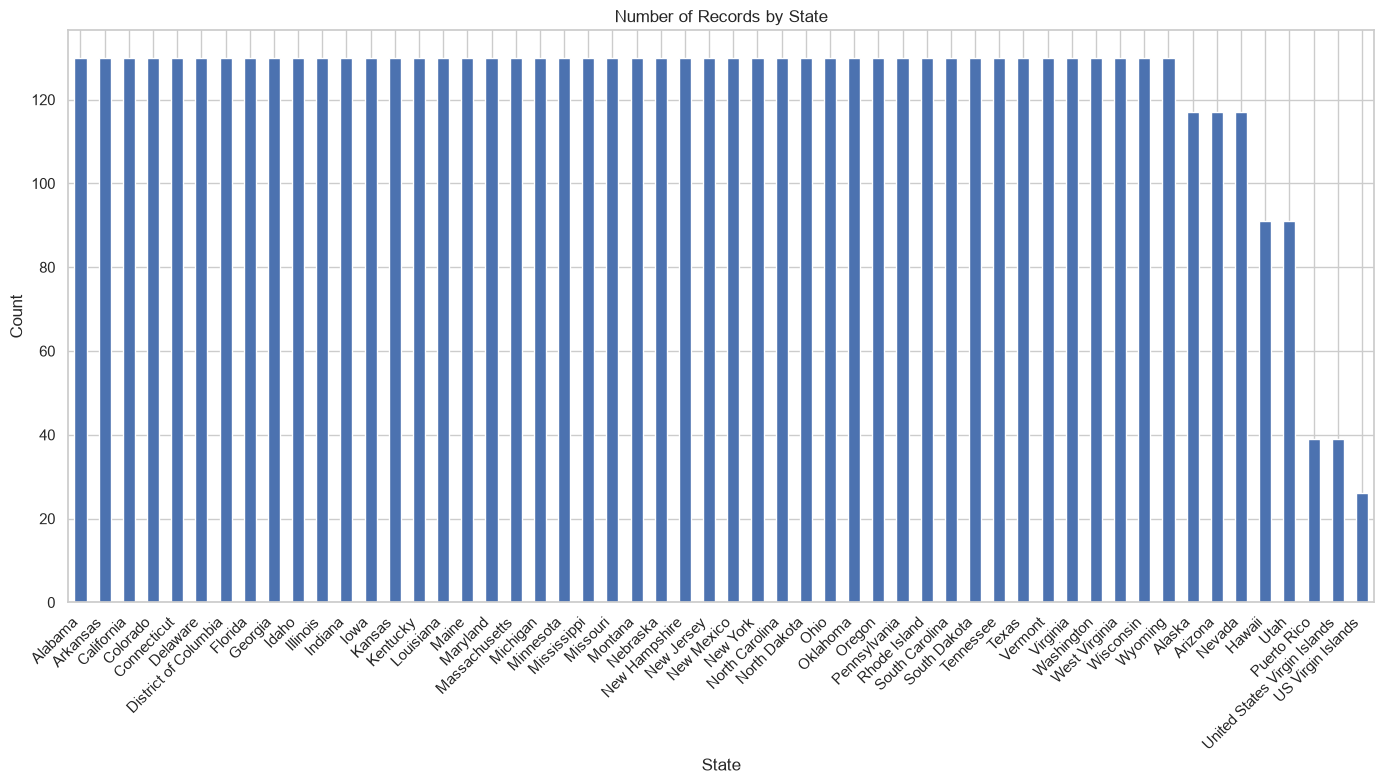

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
state_counts.plot(kind='bar', ax=ax)
ax.set_title('Number of Records by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Year Frequency

In [8]:
year_counts = df['year'].value_counts().sort_index()
print(f"Years in dataset: {sorted(df['year'].unique())}")
year_counts

Years in dataset: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


year
2014    598
2015    637
2016    637
2017    663
2018    663
2019    676
2020    676
2021    689
2022    689
2023    689
Name: count, dtype: int64

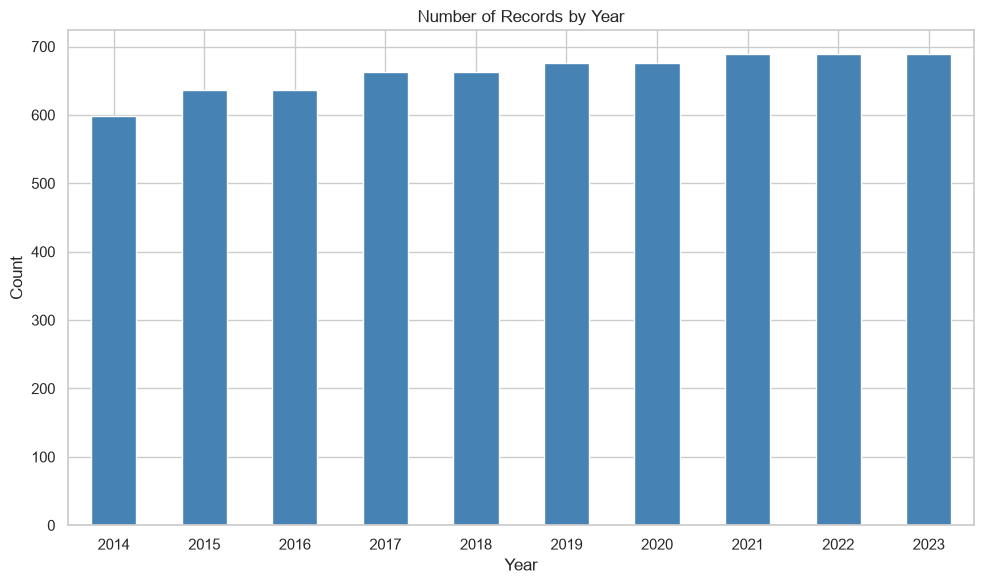

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
year_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Records by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Month Frequency

In [10]:
month_counts = df['month'].value_counts().sort_index()
print(f"Months in dataset: {sorted(df['month'].unique())}")
month_counts

Months in dataset: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


month
0     509
1     509
2     509
3     509
4     509
5     509
6     509
7     509
8     509
9     509
10    509
11    509
12    509
Name: count, dtype: int64

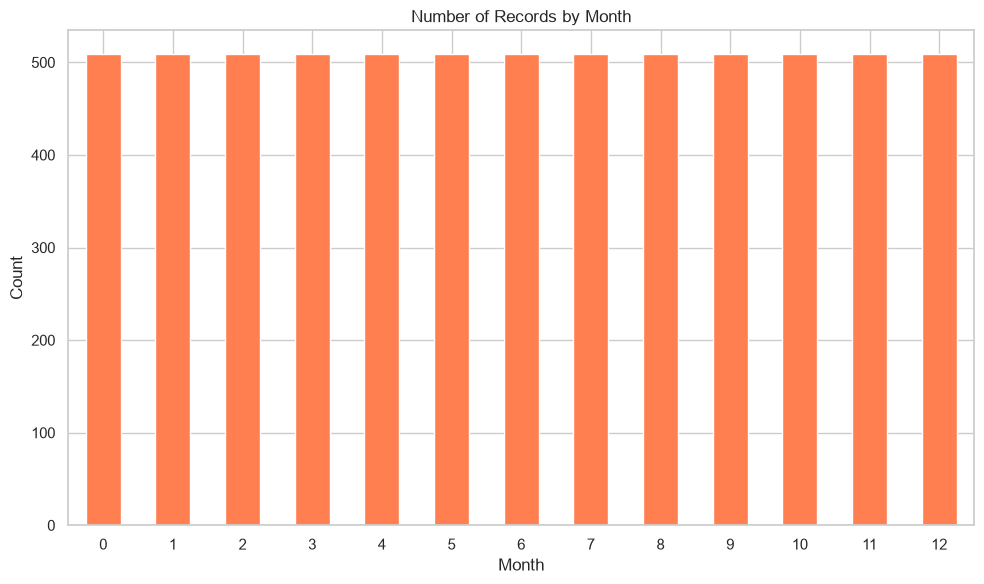

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
month_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Number of Records by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Outage Count Distribution

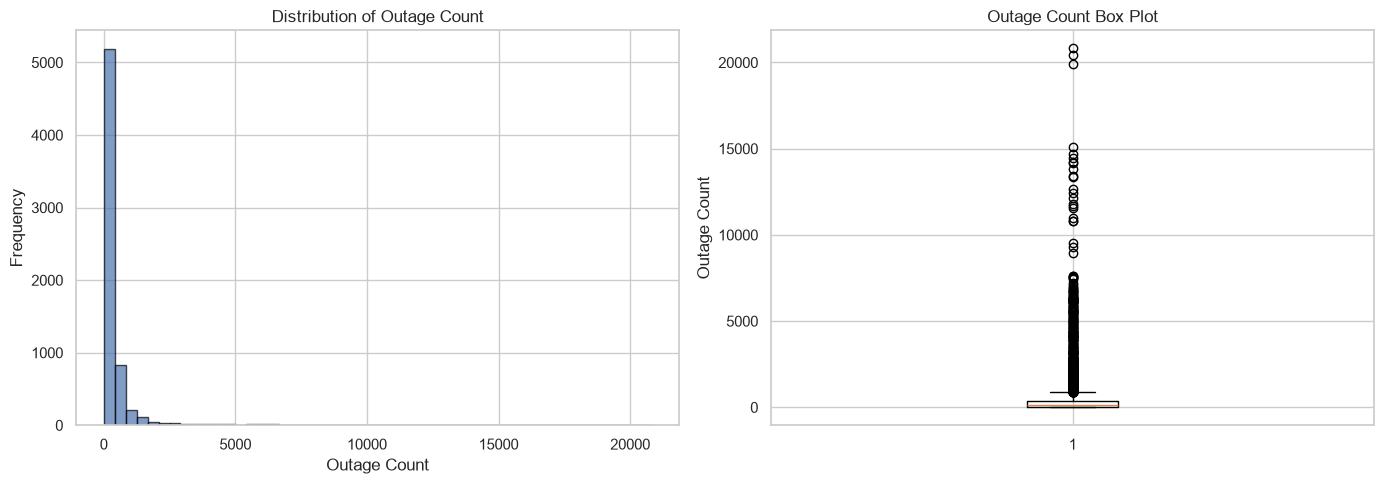

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['outage_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Outage Count')
axes[0].set_xlabel('Outage Count')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['outage_count'].dropna())
axes[1].set_title('Outage Count Box Plot')
axes[1].set_ylabel('Outage Count')

plt.tight_layout()
plt.show()

## Max Outage Duration Distribution

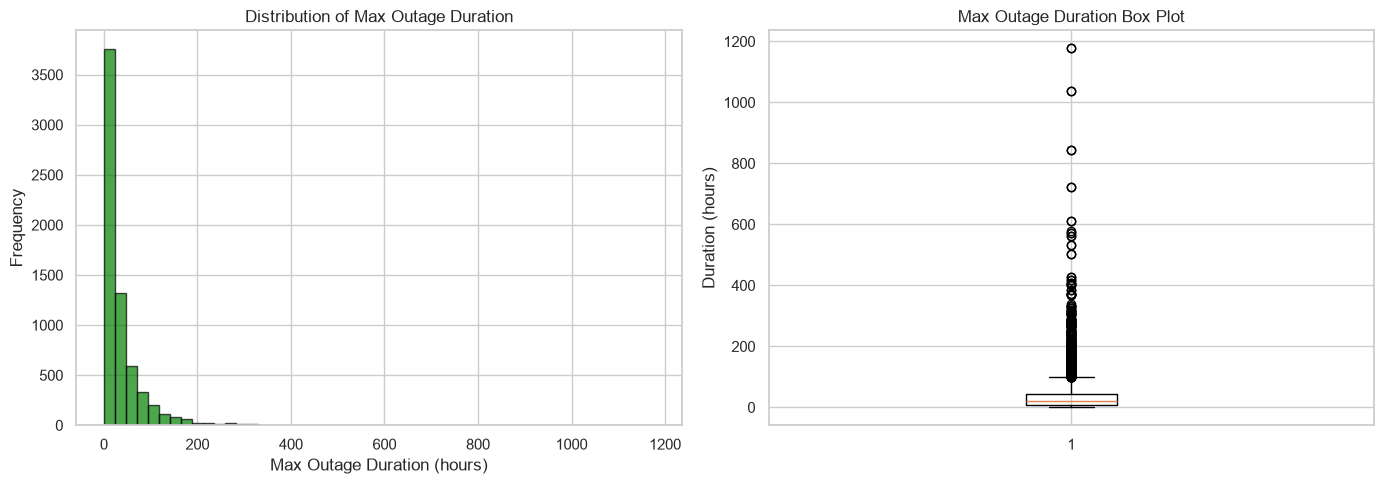

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['max_outage_duration'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('Distribution of Max Outage Duration')
axes[0].set_xlabel('Max Outage Duration (hours)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['max_outage_duration'].dropna())
axes[1].set_title('Max Outage Duration Box Plot')
axes[1].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

## Customer Weighted Hours Distribution

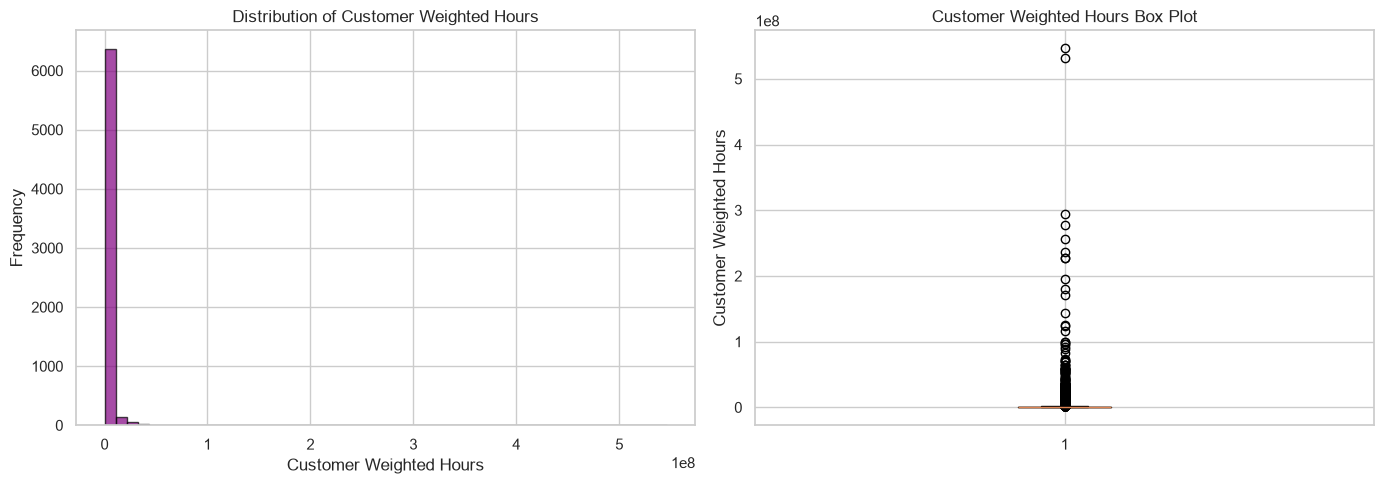

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['customer_weighted_hours'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_title('Distribution of Customer Weighted Hours')
axes[0].set_xlabel('Customer Weighted Hours')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['customer_weighted_hours'].dropna())
axes[1].set_title('Customer Weighted Hours Box Plot')
axes[1].set_ylabel('Customer Weighted Hours')

plt.tight_layout()
plt.show()

## Total Outages by State

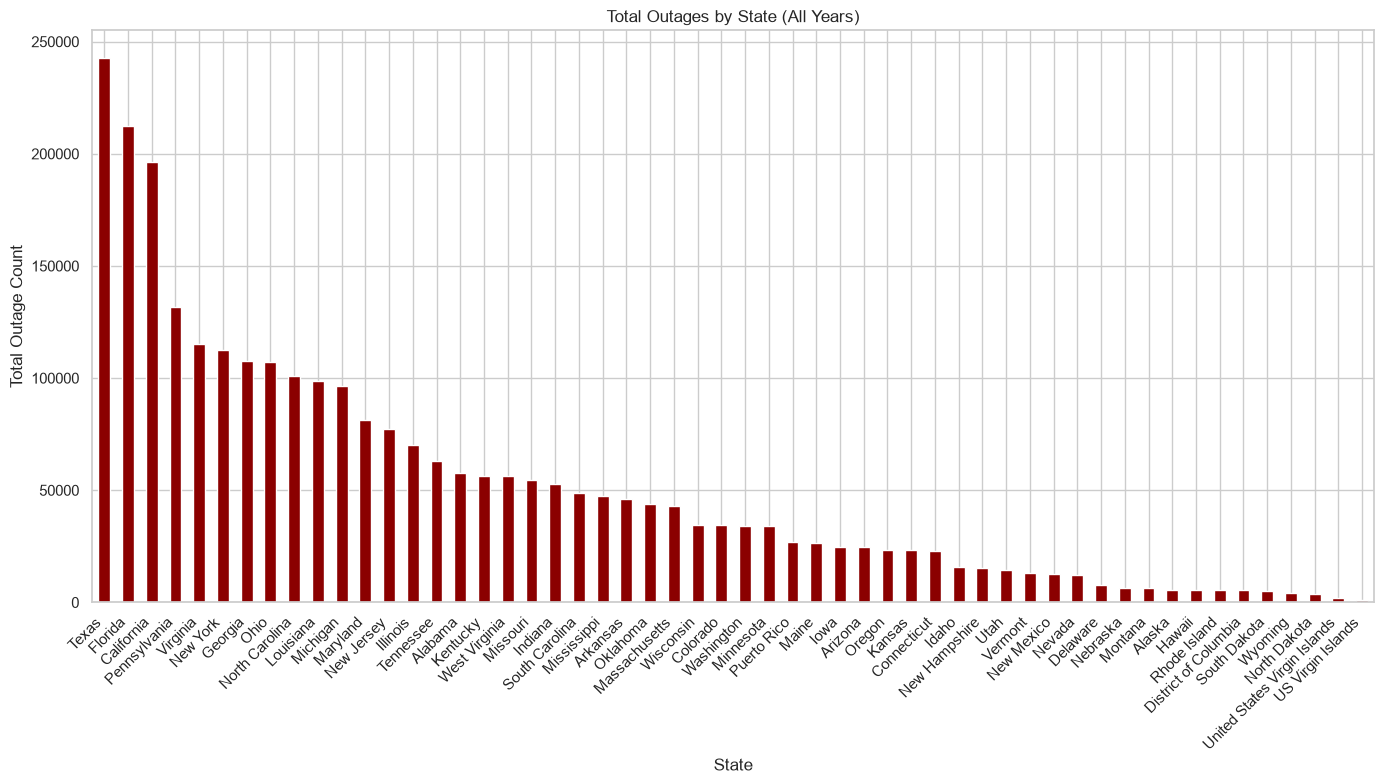

In [15]:
outages_by_state = df.groupby('state')['outage_count'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
outages_by_state.plot(kind='bar', ax=ax, color='darkred')
ax.set_title('Total Outages by State (All Years)')
ax.set_xlabel('State')
ax.set_ylabel('Total Outage Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Total Outages by Year

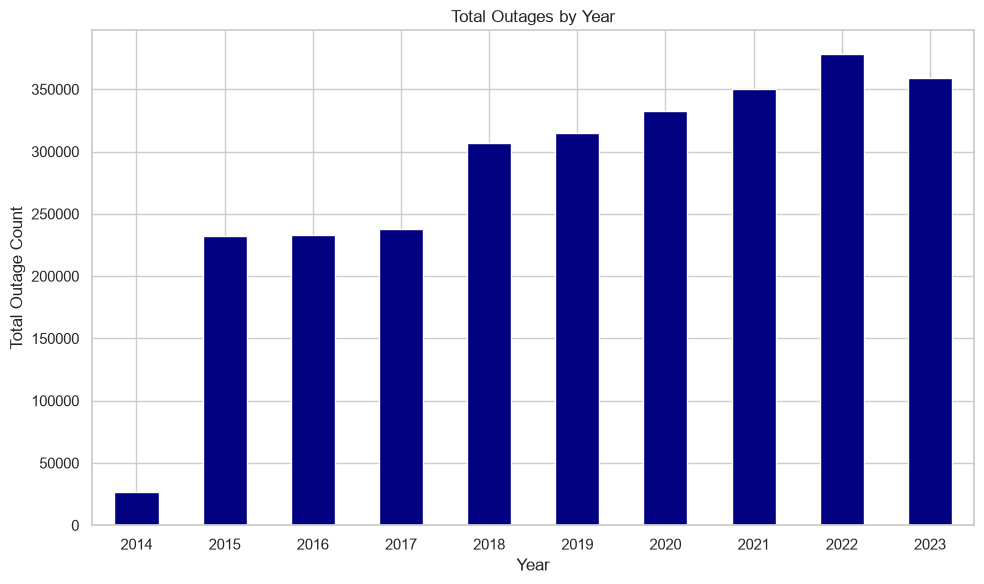

In [16]:
outages_by_year = df.groupby('year')['outage_count'].sum().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
outages_by_year.plot(kind='bar', ax=ax, color='navy')
ax.set_title('Total Outages by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Total Outage Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()